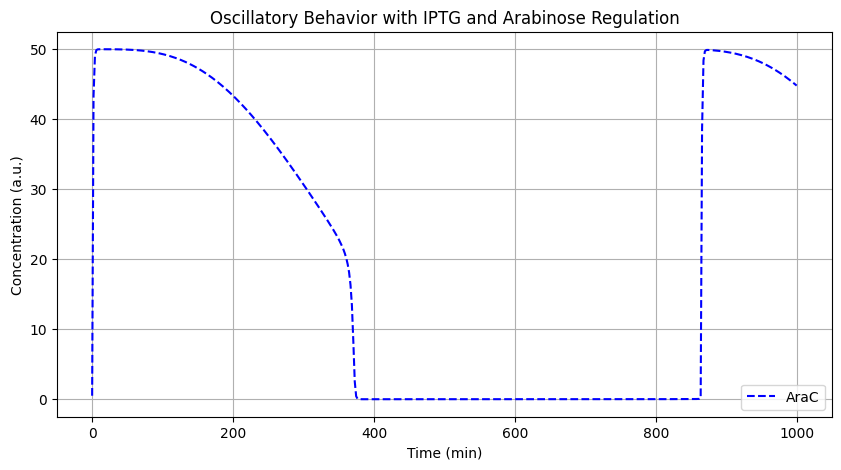

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import math

# Define the system of differential equations with explicit delay in LacI repression
# Corrected: GFP expression is activated by AraC (with arabinose) and inhibited by LacI
# AraC also positively regulates itself, LacI, and GFP
# IPTG inhibits LacI repression, and arabinose activates the plac/ara promoter

def oscillator_corrected(y, t, alpha_A, alpha_L, gamma_A, gamma_L, n, m, tau, arabinose, IPTG):
    A, L = y  # A = AraC, L = LacI, G = GFP
   
    # Implementing explicit delay in LacI repression
    #L_delayed =  * L  # Simulating transcriptional delay for LacI repression

    # Corrected ODEs where AraC activates itself, LacI, and GFP, while LacI represses all three
    dA_dt = alpha_A * (araleak + arabinose * A**m) / (1 + arabinose * A**m + (L**n)*(KdIPTG/(KdIPTG+IPTG)))   - gamma_A * A  # AraC positively regulates itself, but is repressed by LacI
    dL_dt = np.exp(-tau) * (alpha_L * (araleak + arabinose * A**m) / (1 + arabinose* A**m + (L**n)*(KdIPTG/(KdIPTG+IPTG)))  - gamma_L * L)  # LacI is activated by AraC but repressed by LacI and repression is activated by IPTG
   
    return [dA_dt, dL_dt]

# Set parameters for oscillation dynamics
araleak = 0.01
alpha_A = 5e1  # Production rate of AraC
alpha_L = 6e1 # Production rate of LacI
KdIPTG = .01
#alpha_G = 7.0   # Production rate of GFP
gamma_A = 1   # Degradation rate of AraC
gamma_L =1   # Degradation rate of LacI
#gamma_G = 0.2   # Degradation rate of GFP
n = 4           # Cooperativity for sharper inhibition
m = 2           # Cooperativity for sharper inhibition

tau = 5.9  # Introduce transcriptional repression delay (units of what?)
arabinose = 10  # External arabinose concentration that activates AraC (mM)
IPTG = 1.2  # External IPTG concentration that inhibits LacI repression (mM)

# Initial conditions
A0 = 0.5  # Initial AraC level
L0 = 0.1  # Initial LacI level
#G0 = 1.8  # Initial GFP level
y0 = [A0, L0]

# Time points for simulation
t = np.linspace(0, 1000, 500)  # Simulate over 200 minutes with 1000 time points

# External IPTG concentration
u = 0.5  # External IPTG level used to modulate LacI repression

# Solve the system with explicit delay using odeint
solution_corrected = odeint(oscillator_corrected, y0, t,
                            args=(alpha_A, alpha_L, gamma_A, gamma_L, n, m, tau, arabinose, IPTG))

# Extract solutions for each variable
A_corrected, L_corrected = solution_corrected.T

# Plot results for oscillations with delay
plt.figure(figsize=(10, 5))
#plt.plot(t, G_corrected, label='GFP (yemGFP)', color='green')  # Fluorescence output
plt.plot(t, A_corrected, label='AraC', color='blue', linestyle='dashed')  # Activator
#plt.plot(t, L_corrected, label='LacI', color='red', linestyle='dotted')  # Repressor
plt.xlabel('Time (min)')  # Label x-axis as time
plt.ylabel('Concentration (a.u.)')  # Label y-axis as concentration
plt.title('Oscillatory Behavior with IPTG and Arabinose Regulation')  # Title of the plot
plt.legend()  # Display legend for labels
plt.grid()  # Show grid for better visualization
plt.show()  # Display the plot
